### Soil water balance module
Based on: Global land-surface evaporation estimated from satellite-based
observations

In [1]:
import matplotlib.pyplot as plt
import model_init as mi
from model_processes import simulate_wb
import pandas as pd
import numpy as np

#segoe ui font
plt.rcParams['font.sans-serif'] = "Segoe UI"

In [2]:
# loop from t=1 to the last time step
for t in range(1, mi.n_steps):
    simulate_wb(t)

### Observation data

In [3]:
#surface soil moisture data extracted from SMAP
smap_ssm=pd.read_excel("./data/smap_surface_sm_boechout_9km.xlsx", index_col=0)
smap_ssm.index=pd.to_datetime(smap_ssm.index) 

#observed water table depth data
obs_water_table=pd.read_csv("./data/monthly_groundwater_depth.csv", index_col=0)
obs_water_table.index=pd.to_datetime(obs_water_table.index)

#soil moisture from sensors
vmc_sensors = pd.read_csv("./data/vmc_sensors.csv", index_col=0, parse_dates=True, dayfirst=True)

#### Outputs: Transform arrays to dataframes

In [4]:
#convert arrays to pandas series
model_arrays = [mi.interception, mi.total_evap, mi.evap_actual_tc, mi.evap_actual_sc, mi.evap_actual_bs, 
     mi.infil, mi.perco, mi.sm, mi.run_off,mi.y]
array_names = ['interception', 'total_evap', 'evap_actual_tc', 'evap_actual_sc', 'evap_actual_bs', 
     'infil', 'perco', 'sm', 'run_off', 'y']

model_df = pd.DataFrame(model_arrays, index=array_names).T
model_df.index = mi.pET_k.index

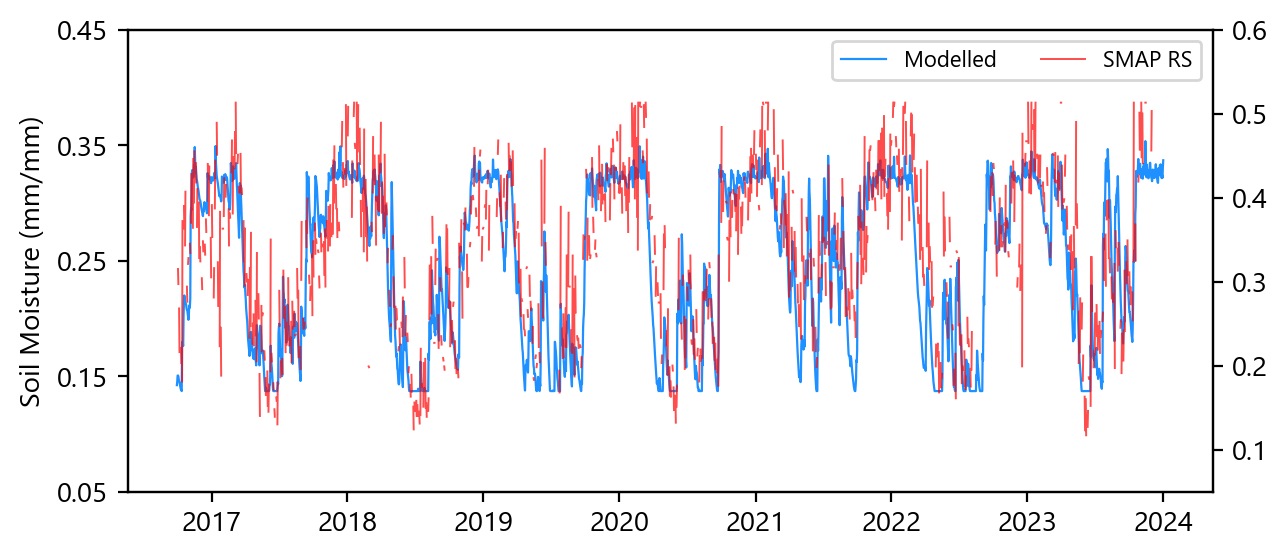

In [5]:
start_date='2016-09-30'#vmc_sensors.index[70]
# end_date=vmc_sensors.index[-1]
end_date='2024-01-01'

fig,ax=plt.subplots(figsize=(7,3), dpi = 200, facecolor='white')
ax1 = ax.twinx()
#plt.plot(500*perco[200:4800])
#plt.plot(E_stress_bs)[200:-1]
ax.plot(model_df['sm'][start_date:end_date], color='dodgerblue',lw = 0.8, label='Modelled')
#ax1.plot(vmc_sensors['s2'][start_date:end_date], color='m', lw = 0.7, label='In situ')


ax1.plot(smap_ssm['soil_moisture_am'][start_date:end_date], c='r', lw=0.7, alpha=0.7, label='SMAP RS')
#ax.axhline(y=mi.s_fc, color='m', lw=0.8, label='Field Capacity')
#ax1.plot(model_df['Available Water Capacity'][start_date:end_date], c='red', alpha=0.3)
ax.set_ylabel('Soil Moisture (mm/mm)');
ax.set_ylim(0.05, 0.45)
ax1.set_ylim(0.05, 0.6)

#yaxis interval
ax.set_yticks(np.arange(0.05, 0.5, 0.10))

#group legend items
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right', ncols=2, fontsize=8)

In [6]:
#monthly percolation
monthly_perco = model_df['perco'].resample('ME').sum()
(monthly_perco).groupby(monthly_perco.index.year).sum().mean()

314.01708569887467

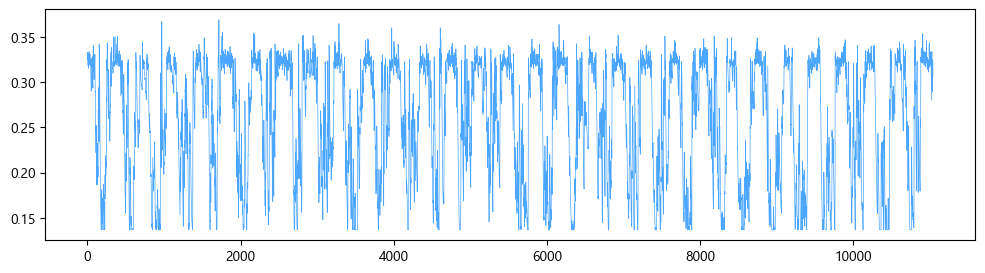

In [7]:
fig, ax = plt.subplots(figsize=(12,3))
#plt.plot(swb['storage_capacity'][1:-1], label='Storage Capacity', color='dodgerblue')
plt.plot(mi.sm[1:-1], label='Infiltration', color='dodgerblue', lw=0.5, alpha=0.8)
#plot percolation 
#plt.plot(swb['percolation'], label='Percolation', color='dodgerblue')

#plt.axhline(y=00, color='m', lw=0.8, label='Field Capacity')
# plt.axhline(y=s_wp*300, color='orange', lw=0.8, label='Wilting Point')
#plt.axhline(y=s_sat*300, color='red', lw=0.8, label='Saturation')

Text(0, 0.5, 'Water Table Depth (mm)')

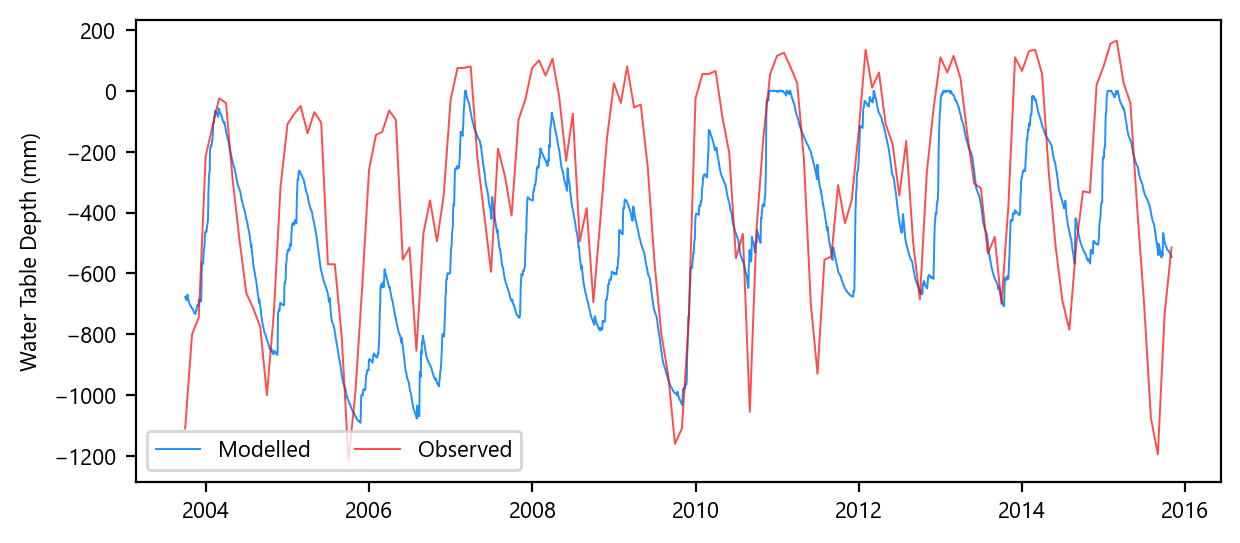

In [8]:
fig, ax = plt.subplots(figsize=(7,3), dpi= 200, facecolor='white')
min_index = obs_water_table.index[0]
max_index = obs_water_table.index[-100]

plt.plot(model_df[min_index:max_index].index, model_df['y'][min_index:max_index],color='dodgerblue', lw=0.7, label='Modelled')

#plot observed water table depth
plt.plot(-1000*obs_water_table['A3'][min_index:max_index], color='r', lw=0.7, label='Observed', alpha=0.7)
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)


plt.legend(loc='best', ncols=2, fontsize=8)
plt.ylabel('Water Table Depth (mm)', fontsize=8)

# plt.axhline(y=s_wp*300, color='orange', lw=0.8, label='Wilting Point')
#plt.axhline(y=s_sat*300, color='red', lw=0.8, label='Saturation')

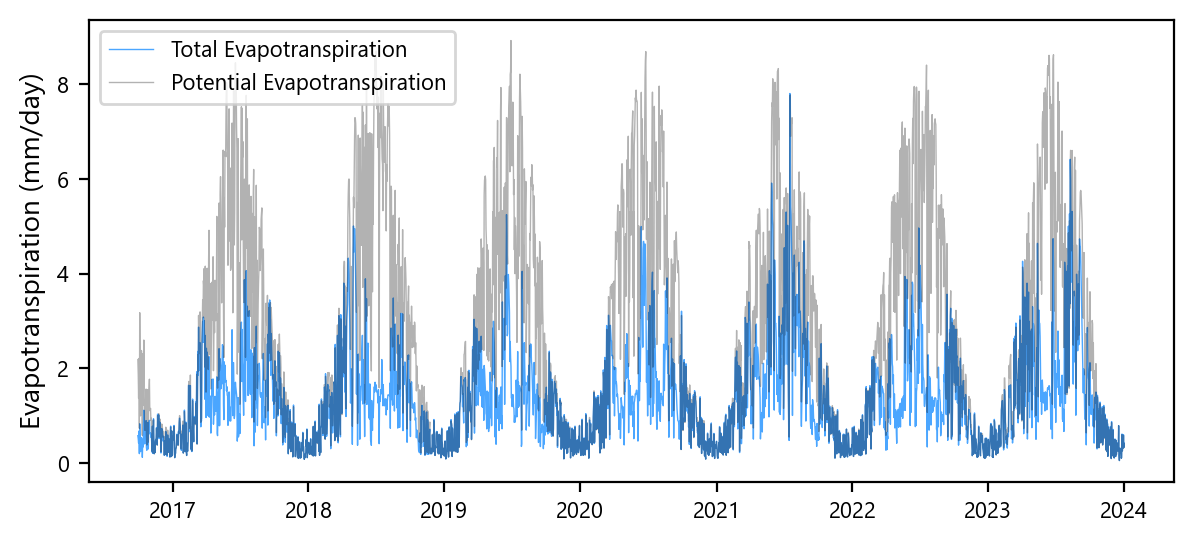

In [9]:
fig,ax=plt.subplots(figsize=(7,3), dpi=200)
# plt.plot(model_df['evap_actual_tc'][start_date:end_date], c='m')
# plt.plot(model_df['evap_actual_sc'][start_date:end_date], c='limegreen')
#plt.plot(model_df['evap_actual_bs'][start_date:end_date], c = 'orange')
plt.plot(model_df['total_evap'][start_date:end_date], c= 'dodgerblue', lw=0.5, alpha=0.8, label='Total Evapotranspiration')
plt.plot(mi.pET_k[start_date:end_date], c =  'black', alpha=0.3, lw=0.5, label='Potential Evapotranspiration')
plt.ylabel('Evapotranspiration (mm/day)')
#ax.plot(model_df['infil'][start_date:end_date], c='blue', alpha=0.3)
plt.legend(loc='best', ncols=1, fontsize=8)
plt.yticks(fontsize=8);
plt.xticks(fontsize=8);

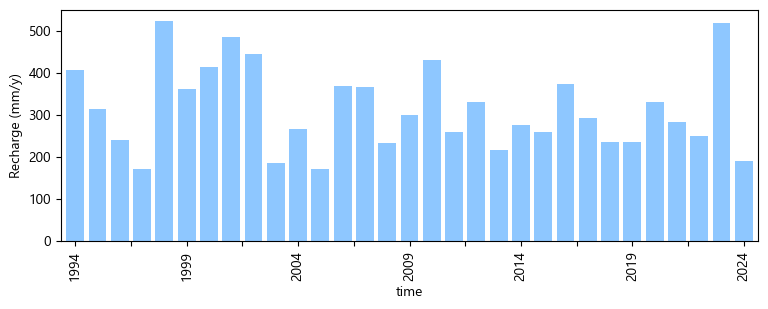

In [10]:
fig,ax=plt.subplots(figsize=(9,3))
monthly_perco.groupby(monthly_perco.index.year).sum().plot(kind='bar', color='dodgerblue', alpha=0.5, width=0.8, ax=ax)
#set axis intervals
ax.set_ylabel('Recharge (mm/y)')
ax1.set_ylabel('Monthly Percolation (mm/month)')
ax.xaxis.set_major_locator(plt.MaxNLocator(15))

Text(0, 0.5, 'Monthly Recharge (mm/month)')

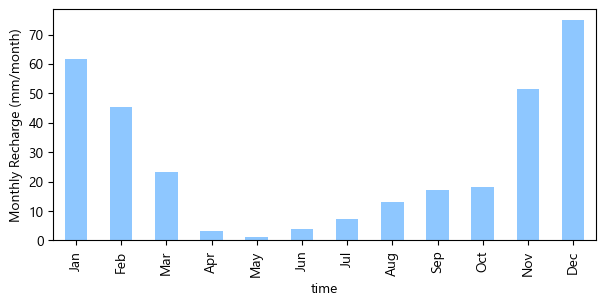

In [11]:
fig,ax=plt.subplots(figsize=(7,3))
monthly_perco.groupby(monthly_perco.index.month).mean().plot(kind='bar', color='dodgerblue', alpha=0.5, width=0.5, ax=ax)
#Add month names to x-axis
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']);
ax.set_ylabel('Monthly Recharge (mm/month)')

### Water Balance

In [12]:
#compute water balance
#output fluxes
annual_fluxes = model_df.resample('YE').sum().mean()

#input fluxes
precip_annual = mi.precip.resample('YE').sum().mean()

wb = precip_annual - annual_fluxes['perco'] - annual_fluxes['total_evap'] #- annual_fluxes['run off']

#excess water
excess_water = mi.precip - model_df['perco'] - model_df['total_evap']

In [13]:
print('Annual Water balance:')
print('-----------------------------')

print('Precipitation:', np.round(precip_annual,2))
print('Total Evapotranspiration:', np.round(annual_fluxes['total_evap'].sum(),2))
print('Percolation:', np.round(annual_fluxes['perco'].sum(),2))
print('Run off:', np.round(annual_fluxes['run_off'].sum(),2))
print('Water balance:', np.round(wb,2))


Annual Water balance:
-----------------------------
Precipitation: 827.96
Total Evapotranspiration: 526.89
Percolation: 314.02
Run off: 2.44
Water balance: -12.94


In [14]:
model_df

,interception,total_evap,evap_actual_tc,evap_actual_sc,evap_actual_bs,infil,perco,sm,run_off,y
time,,,,,,,,,,
1994-01-01,0.100,0.000000,0.500000,0.500000,0.500000,0.1605,0.000000,0.321000,0.0,0.000000
1994-01-02,0.125,0.181030,0.021759,0.020563,0.013708,4.2750,2.953279,0.325219,0.0,0.000000
1994-01-03,0.125,0.172188,0.018326,0.017318,0.011545,6.3750,5.315452,0.328594,0.0,0.000000
1994-01-04,0.125,0.508000,0.148738,0.140557,0.093705,2.3750,2.989036,0.325270,0.0,0.000000
1994-01-05,0.125,0.185483,0.023488,0.022197,0.014798,10.7750,8.396873,0.332996,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...
2024-03-23,0.125,2.161056,0.790701,0.747213,0.498142,4.7750,2.578270,0.324683,0.0,-14.585002
2024-03-24,0.125,1.916273,0.695640,0.657380,0.438253,0.8750,0.132090,0.321189,0.0,-17.177241
2024-03-25,0.000,3.102410,1.204820,1.138555,0.759036,0.0000,0.000000,0.310847,0.0,-22.443583


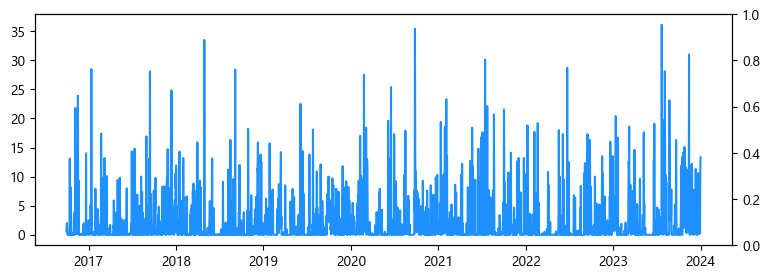

In [15]:
#check precipitation and evaporation
fig,ax=plt.subplots(figsize=(9,3))
ax1 = ax.twinx()
ax.plot(mi.precip[start_date:end_date], color='dodgerblue', label='Precipitation')
#ax1.plot(model_df['total_evap'][start_date:end_date], c='orange', label='Evapotranspiration')

In [16]:
import model_init as mi
import numpy as np
from infiltration_models import InfiltrationModel

def simulate_wetland(time):

    area_wl = mi.top_length * mi.top_length
    V_initial = mi.vol_wl[time-1]         # m3
    h_initial = mi.y_wl[time-1] / 1000.0  # m

    # 0) If dry, zero everything and exit
    if V_initial <= 0 or h_initial <= 0:
        mi.vol_wl[time]     = 0.0
        mi.y_wl[time]       = 0.0
        mi.E_veg_wl[time]   = 0.0
        mi.E_wat_wl[time]   = 0.0
        mi.infil_wl[time]   = 0.0


    # Partition PET into veg vs open‑water, enforce ET ≤ PET
    PET      = mi.pET_k.iloc[time]    # mm
    frac_veg = mi.frac_wl_veg
    pot_veg  = frac_veg * PET
    pot_wet  = (1 - frac_veg) * PET
    tot_pot  = pot_veg + pot_wet
    if tot_pot > PET:
        scale = PET/tot_pot
        pot_veg *= scale
        pot_wet *= scale

    mi.E_veg_wl[time] = pot_veg
    mi.E_wat_wl[time] = pot_wet

    # Convert rainfall & ET from mm to m3 with wetland area
    P        = mi.precip.iloc[time]
    V_in     = (P       / 1000.0) * area_wl  # m3
    V_evveg  = (pot_veg / 1000.0) * area_wl  # m3
    V_evw    = (pot_wet / 1000.0) * area_wl  # m3

    # Infiltration/drainage
    infil_mm = InfiltrationModel(mi.Ks, mi.S).valiantzas_model(mi.dt) * 24.0
    infil_mm = min(infil_mm, mi.y_wl[time-1])

    
    V_inf    = (infil_mm / 1000.0) * area_wl
    mi.infil_wl[time] = infil_mm
    mi.sm_wl[time]    = mi.sm_wl[time-1] + infil_mm/mi.soil_depth  # m3/m3
    mi.sm_wl[time]    = max(0.0, min(mi.s_sat, mi.sm_wl[time]))  # m3/m3

    # Volume update
    V_new = V_initial + V_in - (V_evveg + V_evw + V_inf)
    max_vol_wl = mi.top_length * mi.top_length * mi.h_max  # m3

    # Spillover 
    if V_new > max_vol_wl:
        V_spill = V_new - max_vol_wl
        V_new   = max_vol_wl
        # record spill as mm of runoff over the wetland fraction
        mi.run_off_wl[time] += (V_spill/area_wl)*1000.0

    # Lower
    V_new = max(0.0, V_new)

    # 7) Store new volume & compute depth
    mi.vol_wl[time] = V_new
    mi.y_wl[time]   = (V_new / area_wl) * 1000.0   # mm


In [17]:
# loop from t=1 to the last time step
for t in range(1, mi.n_steps):
    simulate_wetland(t)

In [18]:
total_infil = mi.infil + mi.infil_wl

In [19]:
diff = (total_infil - mi.infil).sum()

In [20]:
total_infil - mi.infil

array([1.60500000e-01, 5.00000000e+01, 9.82375735e+02, ...,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [21]:
diff/mi.infil.sum() * 100

82.40471693639991

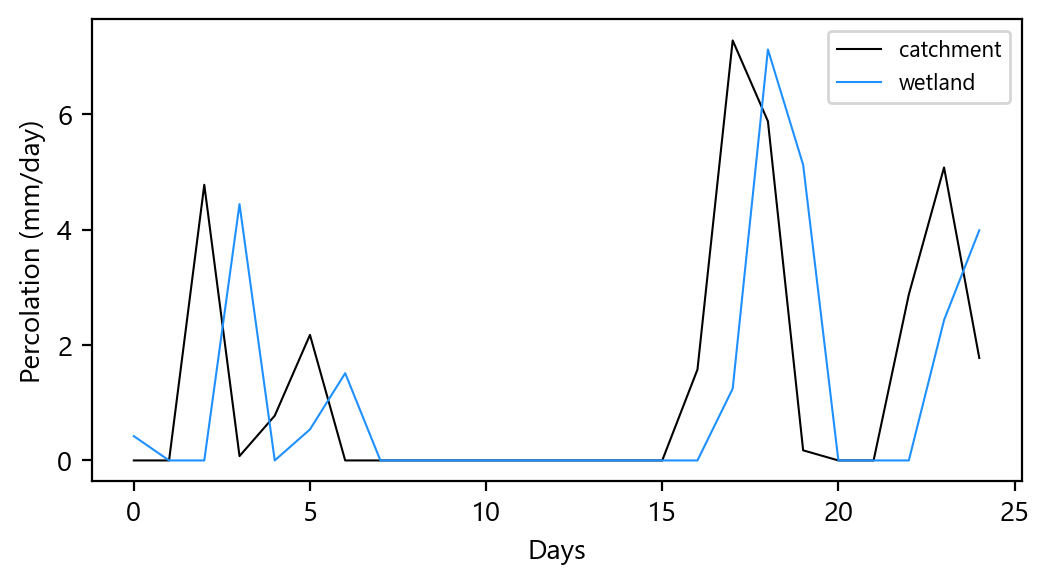

In [69]:
fig, ax = plt.subplots(figsize=(6,3), dpi=200, facecolor='white')
plt.plot(mi.infil[35:60], color='k', lw=0.75, label='catchment')
plt.plot(mi.infil_wl[35:60], color='dodgerblue', lw=0.75, label='wetland')
# plt.plot(total_infil[20:100], color='b', lw= 0.9, label='with wetland')
# plt.plot(mi.y_wl[20:100], color='orange', lw=0.5)
plt.ylabel('Percolation (mm/day)')
plt.xlabel('Days')
plt.legend(loc='best', ncols=1, fontsize=8)


In [30]:
#convert infil arrays to pandas series and assign index
infil_arrays = [mi.infil, mi.infil_wl, total_infil]
infil_names = ['infil', 'infil_wl', 'total_infil']
infil_df = pd.DataFrame(infil_arrays, index=infil_names).T
infil_df.index = mi.pET_k.index

In [36]:
infil_df[20:].resample('ME').sum().plot(kind='bar', color='dodgerblue', alpha=0.5, width=0.8, ax=ax)

<Axes: xlabel='time', ylabel='Percolation (mm/day)'>

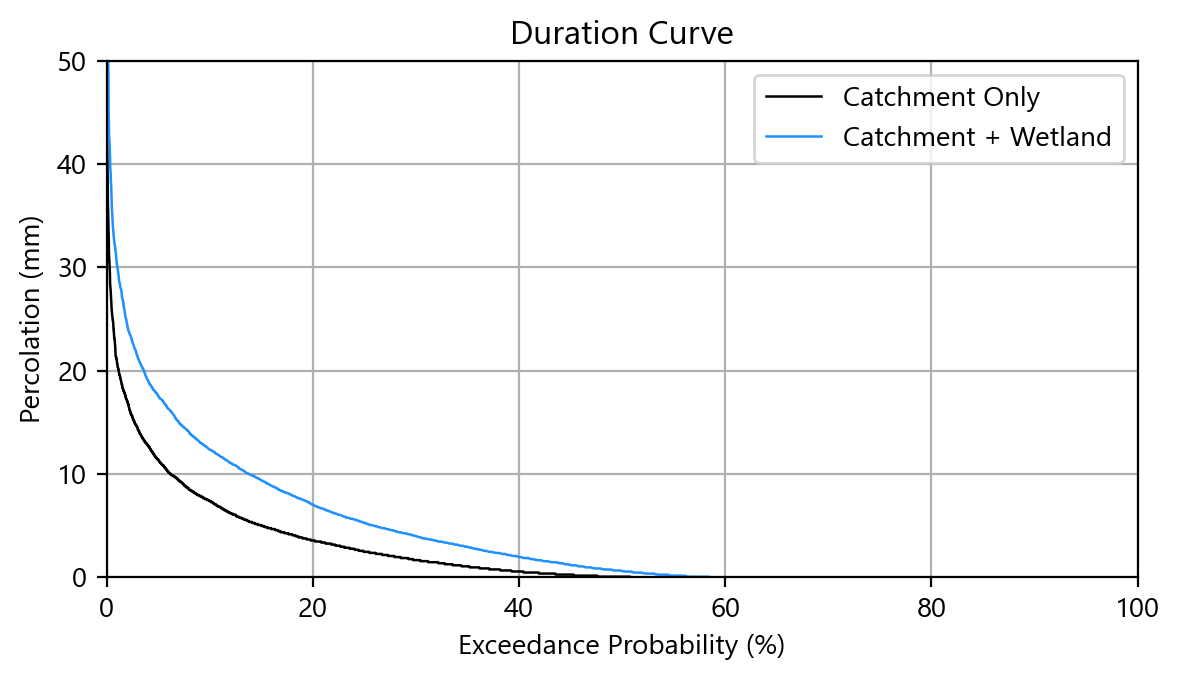

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assuming you already have 'infil_df' with 'infil', 'infil_wl', 'total_infil' columns
# Example if not yet:
# infil_df = pd.DataFrame(infil_arrays, index=infil_names).T
# infil_df.index = mi.pET_k.index

# Select one or multiple columns you want to plot
flows_to_plot = ['infil', 'total_infil']  # or whatever you want
labels = ['Catchment Only', 'Catchment + Wetland']
colors = ['k', 'dodgerblue']

fig, ax = plt.subplots(figsize=(6,3.5), dpi=200, facecolor='white')

for flow_name, label, color in zip(flows_to_plot, labels, colors):
    # 1. Drop NaNs if any
    flow_series = infil_df[20:][flow_name].dropna()
    
    # 2. Sort in descending order
    flow_sorted = flow_series.sort_values(ascending=False)
    
    # 3. Calculate exceedance probability
    ranks = np.arange(1, len(flow_sorted)+1)
    exceedance = 100 * ranks / (len(flow_sorted)+1)
    
    # 4. Plot
    ax.plot(exceedance, flow_sorted, label=label, color=color, lw=0.9)

ax.set_xlabel('Exceedance Probability (%)')
ax.set_ylabel('Percolation (mm)')
ax.set_title('Duration Curve')
ax.legend()
ax.grid(True)
ax.set_xlim(0, 100)
ax.set_ylim(0, 50)  # Set y-axis limit to auto-adjust based on data
#ax.set_yscale('log')  # Optional: log scale is common for FDCs if range is wide

plt.tight_layout()
plt.show()


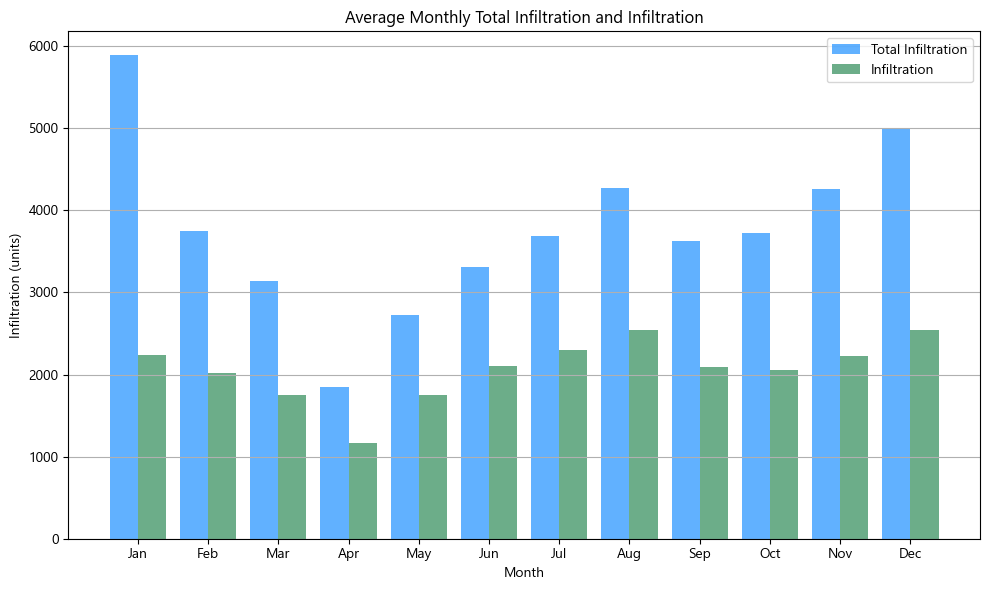

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Add a 'month' column (1–12)
infil_df['month'] = infil_df.index.month

# Group by month and sum
monthly_infil = infil_df.groupby('month')[['total_infil', 'infil']].sum()

# Plot
fig, ax = plt.subplots(figsize=(10,6))

x = monthly_infil.index

width = 0.4  # Width of each bar

# Plot side-by-side bars
ax.bar(x - width/2, monthly_infil['total_infil'], 
       width=width, color='dodgerblue', alpha=0.7, label='Total Infiltration')

ax.bar(x + width/2, monthly_infil['infil'], 
       width=width, color='seagreen', alpha=0.7, label='Infiltration')

# Formatting
ax.set_xlabel('Month')
ax.set_ylabel('Infiltration (units)')
ax.set_title('Average Monthly Total Infiltration and Infiltration')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()


In [23]:
import xarray as xr
pre = xr.open_dataset(r"W:\VUB\_main_research\mHM\mhm_belgium\RMI\meteo\pre\pre.nc")
pet = xr.open_dataset(r"W:\VUB\_main_research\mHM\mhm_belgium\RMI\meteo\pet\pet.nc")

#extract timeseries from lat=51.167, lon =5.539
pre_ts = pre['pre'].sel(lat=51.167, lon=5.539, method='nearest')
pet_ts = pet['pet'].sel(lat=51.167, lon=5.539, method='nearest')

(11044,)